# Can a neural network correct numerical errors due to time scheme ?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import * 
import os
path = 'data/correct_num_err'
dataset_name = 'pendulum'
data_integration_method = 'RK4'
duration = 20
dt_num = 0.05
train, val, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)
for i, train_data in enumerate(train):
    print(train_data["states"].shape)
for i, test_data in enumerate(test):
    print(test_data["states"].shape)

torch.Size([25, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])
torch.Size([1, 2, 401])


### Load models

In [7]:
# load model 
import json 
from networks import *
import jax
import equinox as eqx
from datasets import *
import os
from forecasters import *

def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method, dt_factor):
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=test.dataset.dt * dt_factor,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op


In [8]:
exp_name = 'true_aug_1_akm7kp32'
model_name = 'model_5.677e-08.eqx'
data_path = 'data/correct_num_err'
model_phy_option = 'true'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK2'
true_aug1, _,_ = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method, dt_factor=2)

exp_name = 'true_aug_2_akm7kp32'
model_name = 'model_2.011e-06.eqx'
data_path = 'data/correct_num_err'
model_phy_option = 'true'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK2'
true_aug2, _,_ = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method, dt_factor=5)

data/correct_num_err/true_aug_1_akm7kp32/model_5.677e-08.eqx
l2
data/correct_num_err/true_aug_2_akm7kp32/model_2.011e-06.eqx
l2


In [9]:
# simulate ground truth data with RK2 
from utils import *

def simulate_ground_truth(dt_factor,integration_method, dataset="test"):
    if dataset == "test":
        data = test
    elif dataset == "train":
        data = train
    elif dataset == "val":
        data = val
    model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
    mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
    model_aug = MLP(key=mkey, state_c=2, hidden=200)
    model_aug = init_linear_weight(model_aug, orthogonal_init, key=ikey, init_gain=0.2) #(dt_factor * train.dataset.dt)**2) 
    net = Forecaster(
        model_phy=model_phy,
        model_aug=model_aug,
        is_augmented=False,
        is_phy="true",
        dt=dt_factor * train.dataset.dt, # enabling comparison with GT for error scheme experiment 
        num_steps=int(train.dataset.num_steps / dt_factor), 
        integration_method=integration_method, # RK2 for error scheme experiment
    )
    losses = []
    for i, val_data in enumerate(data):
        states = jnp.array(val_data['states'])[:,:,::dt_factor]
        y0 = states[:,:,0]
        pred = jax.vmap(net)(y0)
        losses.append(((pred - states)**2))
    print(np.array(losses).mean())
    return np.array(losses), net

loss_true1, net_true1 = simulate_ground_truth(2, 'RK2', 'val')

1.4803512e-06


In [32]:
loss_true1, net_true1 = simulate_ground_truth(2, 'RK2', 'val')
loss_true2, net_true2 = simulate_ground_truth(5, 'RK2', 'val')

1.4803512e-06
5.0196613e-05


In [15]:
net_true1.derivative_estimator(jnp.array([0.,1.]),0)

Array([ 1. , -0.2], dtype=float32)

In [16]:
def F(y,t):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2 * y[1]])

Array([ 1. , -0.2], dtype=float32)

In [27]:
t1=20
t0=0
traj1 = net_true1(jnp.array([1.5,1.]))
trajrk = RK_solver_fixed(F, jnp.array([1.5,1.]), 0.05*2, (t1-t0)/(0.05*2), RK_tableaux["RK2"])[0]

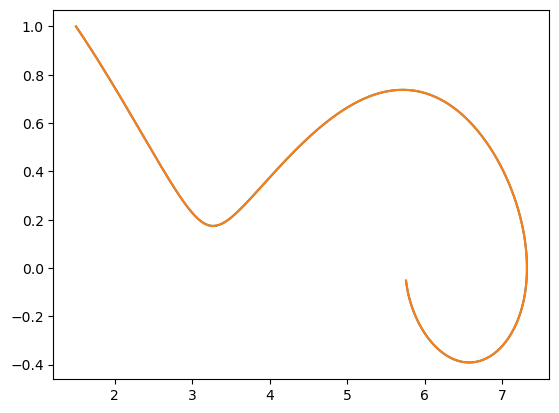

In [28]:
plt.plot(traj1[0,:], traj1[1,:])
plt.plot(trajrk[0,:], trajrk[1,:])

In [29]:
np.abs(traj1-trajrk).mean()

0.0

In [32]:
t0 =0
t1 = 20
def F(y,t):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2 * y[1]])
dt_truth = 0.05
def simulate_ground_truth2(dt_factor,integration_method, dataset="test"):
    if dataset == "test":
        data = test
    elif dataset == "train":
        data = train
    elif dataset == "val":
        data = val
    losses = []
    for i, val_data in enumerate(data):
        dt = dt_factor * dt_truth
        states = jnp.array(val_data['states'])[:,:,::dt_factor]
        if dataset == "test":
            print(states.shape)
            y0 = states[0,:,0]
            pred,_,_,_ = RK_solver_fixed(F, y0, dt, (t1-t0)/dt, RK_tableaux[integration_method])
            losses.append(((pred - states)**2))
        else: 
            print(states.shape)
            for k in range(states.shape[0]):
                y0 = states[k,:,0]
                pred,_,_,_ = RK_solver_fixed(F, y0, dt, (t1-t0)/dt, RK_tableaux[integration_method])
                losses.append(((pred - states)**2))
    print(losses[0].mean())
    return np.array(losses) #[0].mean(axis=(1,2))

### Error on train, val, test (in)

In [71]:
def simulate_model(net, dt_factor,integration_method, dataset="test"):
    if dataset == "test":
        data = test
        state = None
        for i, val_data in enumerate(data):
            if state is None:
                state = val_data['states']
            else:
                state = np.concatenate((state, val_data['states']), axis=0)
        states = jnp.array(state)[:,:,::dt_factor]
        y0 = states[:,:,0]
        pred = jax.vmap(net)(y0)
        return (pred - states)**2
    
    elif dataset == "train":
        data = train
        for i, val_data in enumerate(data):
            states = jnp.array(val_data['states'])[:,:,::dt_factor]
            y0 = states[:,:,0]
            pred = jax.vmap(net)(y0)
        return (pred - states)**2
    elif dataset == "val":
        data = val
        for i, val_data in enumerate(data):
            states = jnp.array(val_data['states'])[:,:,::dt_factor]
            y0 = states[:,:,0]
            pred = jax.vmap(net)(y0)
        return (pred - states)**2

In [76]:
loss_true1_aug = simulate_model(true_aug1, 2, 'RK2', 'val')
loss_true2_aug = simulate_model(true_aug2, 5, 'RK2', 'val')
loss_true1_train_aug = simulate_model(true_aug1, 2, 'RK2', 'train')
loss_true2_train_aug = simulate_model(true_aug2, 5, 'RK2', 'train')
loss_true1_aug_test = simulate_model(true_aug1, 2, 'RK2', 'test')
loss_true2_aug_test = simulate_model(true_aug2, 5, 'RK2', 'test')

In [77]:
loss_true1 = simulate_model(net_true1, 2, 'RK2', 'val')
loss_true2 = simulate_model(net_true2, 5, 'RK2', 'val')
loss_true1_train = simulate_model(net_true1, 2, 'RK2', 'train')
loss_true2_train = simulate_model(net_true2, 5, 'RK2', 'train')
loss_true1_test = simulate_model(net_true1, 2, 'RK2', 'test')
loss_true2_test = simulate_model(net_true2, 5, 'RK2', 'test')

In [89]:
loss_true1_aug_test.mean(axis=0).mean(), loss_true1_aug_test.mean()

(Array(4.791733e-07, dtype=float32), Array(4.791733e-07, dtype=float32))

In [99]:
states_test = None
for i, val_data in enumerate(test):
    if states_test is None:
        states_test = val_data['states']
    else:
        states_test = np.concatenate((states_test, val_data['states']), axis=0)
states_test.shape

(25, 2, 401)

In [101]:
y0_22 = states_test[22,:,0]
y0_22

array([0.5278256, 1.3292698], dtype=float32)

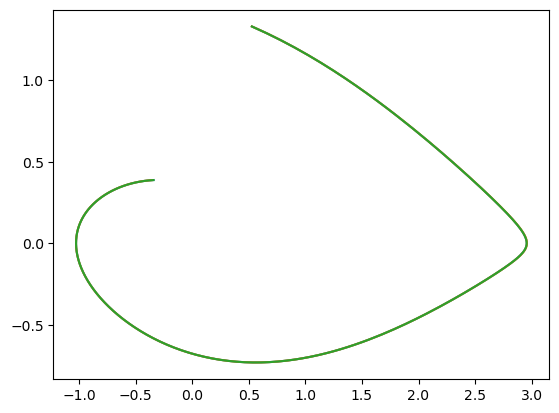

In [109]:
traj = net_true1(jnp.array(y0_22))
plt.plot(traj[0,:], traj[1,:])
plt.plot(states_test[22,0,:], states_test[22,1,:])
plt.plot(trajrk[0,:], trajrk[1,:])

In [132]:
# sanity checks net=rk (pred) and dataloader=rk (truth) for true model
trajrk = RK_solver_fixed(F, jnp.array(y0_22), 0.05*2, (t1-t0)/(0.05*2), RK_tableaux["RK2"])[0]
truthrk = RK_solver_fixed(F, jnp.array(y0_22), 0.05, (t1-t0)/(0.05), RK_tableaux["RK4"])[0]
np.abs(trajrk - traj).mean(), np.abs(states_test[22,:,:] - truthrk).mean()

(0.0, 0.0)

Notre dataloader, RK_solver_fixed et net donnent mêmes résultats

In [141]:
# sanity checks net=rk (pred) for aug model
F_aug1 = true_aug1.derivative_estimator
F_aug2 = true_aug2.derivative_estimator
y0 = jnp.array([y0_22, [0.2,0.2]])
traj1 = jax.vmap(true_aug1)(y0)
trajrk11 = RK_solver_fixed(F_aug1, jnp.array(y0_22), 0.05*2, (t1-t0)/(0.05*2), RK_tableaux["RK2"])[0]
trajrk12 = RK_solver_fixed(F_aug1, jnp.array([0.2,0.2]), 0.05*2, (t1-t0)/(0.05*2), RK_tableaux["RK2"])[0]

np.abs(traj1[0] - trajrk11).mean(), np.abs(traj1[1] - trajrk12).mean()

(0.0, 0.0)

Utiliser net ou RK_solver_fixed donne les mêmes résultats, qu'on utilise jax.vmap ou trajectoire par trajectoire.

In [110]:
np.abs(states_test[22,:,:][:,::2] - traj[:,:]).mean(), np.abs(states_test[22,:,:][:,::2] - trajrk[:,:]).mean()

(0.006319574, 0.006319574)

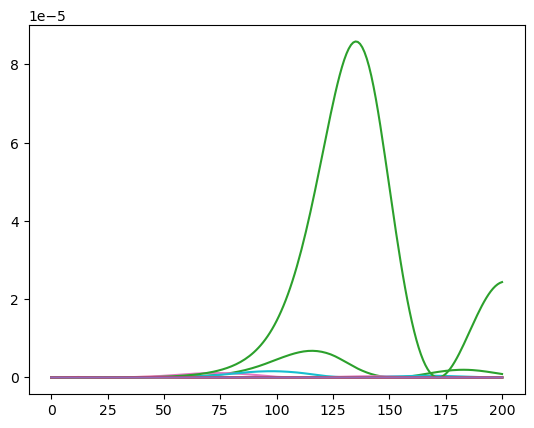

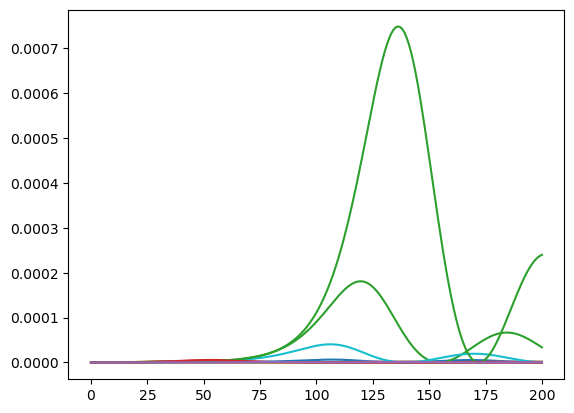

In [96]:
for k in range(25):
    plt.plot(loss_true1_aug_test[k,0,:], label=k)
plt.figure()
for k in range(25):
    plt.plot(loss_true1_test[k,0,:])

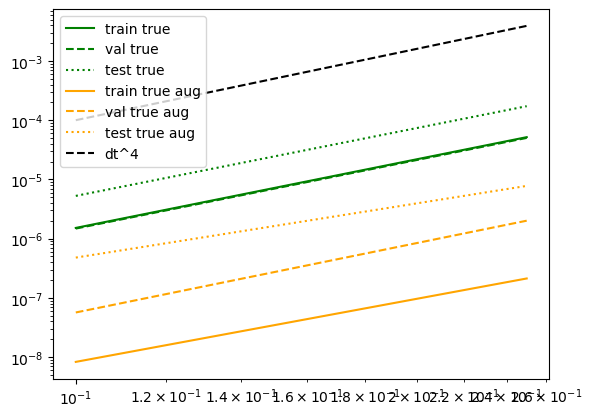

In [125]:
dt_list = np.array([2,5])*0.05
plt.plot(dt_list, [loss_true1_train.mean(), loss_true2_train.mean()], label="train true", color="green")
plt.plot(dt_list, [loss_true1.mean(), loss_true2.mean()], label="val true", color="green", linestyle='--')
plt.plot(dt_list, [loss_true1_test.mean(), loss_true2_test.mean()], label="test true", color="green", linestyle=':')

plt.plot(dt_list, [loss_true1_train_aug.mean(), loss_true2_train_aug.mean()], label="train true aug", color='orange')
plt.plot(dt_list, [loss_true1_aug.mean(), loss_true2_aug.mean()], label="val true aug", color='orange', linestyle='--')
plt.plot(dt_list, [loss_true1_aug_test.mean(), loss_true2_aug_test.mean()], label="test true aug", color='orange', linestyle=':')
plt.plot(dt_list, dt_list**4, label="dt^4", color='black', linestyle='--')
plt.legend()
plt.xscale('log')
plt.yscale('log')

In [114]:
loss_true1_train.shape

(25, 2, 201)

In [116]:
# all of these trajectories are "in"
true_in1 = np.concatenate((loss_true1_train, loss_true1, loss_true1_test), axis=0)
true_in2 = np.concatenate((loss_true2_train, loss_true2, loss_true2_test), axis=0)
aug_in1 = np.concatenate((loss_true1_train_aug, loss_true1_aug, loss_true1_aug_test), axis=0)
aug_in2 = np.concatenate((loss_true2_train_aug, loss_true2_aug, loss_true2_aug_test), axis=0)

Text(0.5, 1.0, 'L1 error, T=20s')

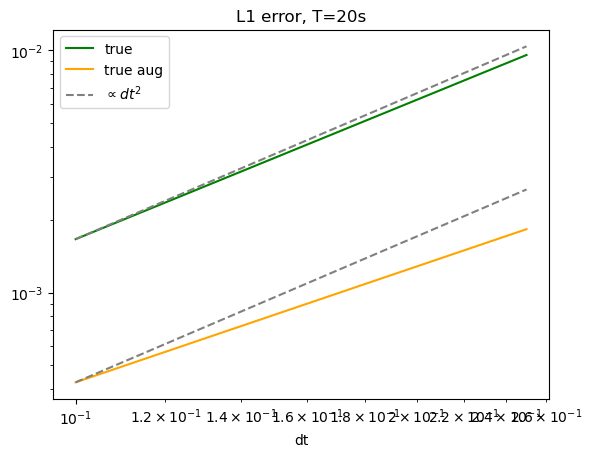

In [129]:
plt.plot(dt_list, [np.sqrt(true_in1.mean()), np.sqrt(true_in2.mean())], label="true", color="green")
plt.plot(dt_list, [np.sqrt(aug_in1.mean()), np.sqrt(aug_in2.mean())], label="true aug", color="orange")
plt.plot(dt_list, (np.sqrt(aug_in1.mean())/(dt_list[0]**2))*dt_list**2, label=r"$\propto dt^2$", color="grey", linestyle='--')
plt.plot(dt_list, (np.sqrt(true_in1.mean())/(dt_list[0]**2))*dt_list**2, color="grey", linestyle='--')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel("dt")
plt.title("L1 error, T=20s")

Text(0.5, 1.0, '$L1/dt^2$, T=20s')

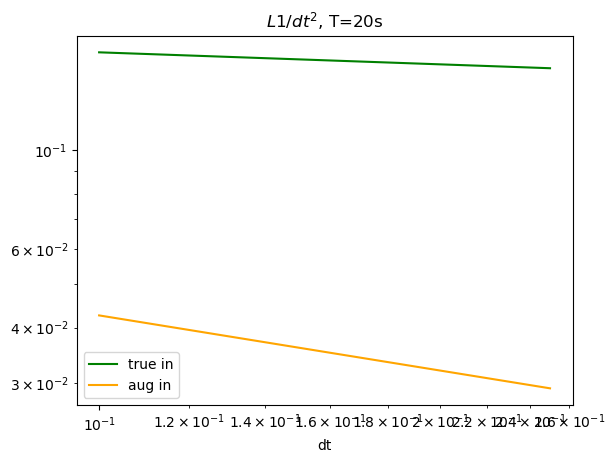

In [130]:
plt.plot(dt_list, np.array([np.sqrt(true_in1.mean()), np.sqrt(true_in2.mean())])/(dt_list**2), label="true in", color="green")
plt.plot(dt_list, np.array([np.sqrt(aug_in1.mean()), np.sqrt(aug_in2.mean())])/(dt_list**2), label="aug in", color="orange")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("dt")
plt.legend()
plt.title(r"$L1/dt^2$, T=20s")

On n'est pas intéressé par train/val/test mais plus par la généralisation: reprendre les points de l'expérience précédente

In [2]:
import itertools
# training ranges
p_min,p_max = -2.15, 2.15
q_min, q_max = -8.03, 7.94
factor=3
q_left = np.linspace(factor*q_min, q_min-1, 3)
q_right = np.linspace(q_max+1, factor*q_max, 3)
q_in = np.linspace(q_min, q_max, 4)
q_out = np.concatenate((q_left, q_right))
p_in = np.linspace(p_min, p_max, 4)
p_left = np.linspace(factor*p_min, p_min-1, 3)
p_right = np.linspace(p_max+1, factor*p_max, 3)
p_out = np.concatenate((p_left, p_right))
q_out, p_out

y0_in = np.array(list(itertools.product(q_in, p_in)))
y0_out = np.array(list(itertools.product(q_out, p_out)))
y0_q_in = np.array(list(itertools.product(q_in, p_out)))
y0_p_in = np.array(list(itertools.product(q_out, p_in)))

In [44]:
def simulate_model_points(net, points, dt_factor):
    y0 = jnp.array(points)
    pred = jax.vmap(net)(y0)
    return pred 

In [45]:
aug1_in = simulate_model_points(true_aug1, y0_in, 2)
aug1_out = simulate_model_points(true_aug1, y0_out, 2)

In [7]:
F_aug2 =true_aug1.derivative_estimator
F_aug5 =true_aug2.derivative_estimator

In [8]:
import pandas as pd 

def compute_trajectories(F_model, y0_list, dt_truth=0.05, dt_factor=1, t1=20):
    y_true_list = []
    y_pred_list = []
    dico = {}
    dt = dt_factor * dt_truth
    for i, y0 in enumerate(y0_list):
        y_true = RK_solver_fixed(F,y0,dt_truth, int((t1 - t0) / dt_truth),RK_tableaux["RK4"])[0][:,::dt_factor] #y(T)
        y_pred = RK_solver_fixed(F_model,y0,dt, int((t1 - t0) / dt),RK_tableaux["RK2"])[0] #y(T)
        y_true_list.append(y_true)
        y_pred_list.append(y_pred)
        dico[i] = {
            "y0": y0,
            "y_true": y_true,
            "y_pred" :y_pred,
            }
    return pd.DataFrame(dico).T

In [21]:
def compute_metrics(data):
    #data = compute_trajectories(F_model, y0_list, dt=0.5, t1=400)
    data["L1"] = data.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
    data["p_inf_true"] = data.apply(lambda x: x["y_true"][1,-1:], axis=1)
    data["p_inf_pred"] = data.apply(lambda x: x["y_pred"][1,-1:], axis=1)
    data["q_inf_true"] = data.apply(lambda x: x["y_true"][0,-1:], axis=1)
    data["q_inf_pred"] = data.apply(lambda x: x["y_pred"][0,-1:], axis=1)
    data["p_inf_pred_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_pred"][1,-20:])), axis=1)
    data["p_inf_true_mean"] = data.apply(lambda x: np.mean(np.abs(x["y_true"][1,-20:])), axis=1)
    data["q_inf_pred_mean"] = data.apply(lambda x: np.mean(x["y_pred"][0,-20:]), axis=1)
    data["q_inf_true_mean"] = data.apply(lambda x: np.mean(x["y_true"][0,-20:]), axis=1)

    # "max" is where p changes sign for the first time
    p_lim_true = data.apply(lambda x: np.where(np.sign(x["y_true"][1,:-1]) - np.sign(x["y_true"][1,1:]) != 0)[0][0], axis=1)
    p_lim_pred = data.apply(lambda x: np.where(np.sign(x["y_pred"][1,:-1]) - np.sign(x["y_pred"][1,1:]) != 0)[0][0], axis=1)
    data["p_lim_true"] = p_lim_true
    data["p_lim_pred"] = p_lim_pred
    print(p_lim_true.max(), p_lim_pred.max())
    data["q_max_pred"] = data.apply(lambda x: x["y_pred"][0,x["p_lim_pred"]], axis=1)
    data["q_max_true"] = data.apply(lambda x: x["y_true"][0,x["p_lim_true"]], axis=1)
    #data["q_max_pred"] = data.apply(lambda x: np.max(np.abs(x["y_pred"][0,1:])), axis=1)
    #data["q_max_true"] = data.apply(lambda x: np.max(np.abs(x["y_true"][0,1:])), axis=1)
    data["q_inf_modulo2pi_pred"] = data.apply(lambda x: min(np.abs(x["q_inf_pred"]%(2*np.pi)), np.abs(x["q_inf_pred"]%(-2*np.pi))), axis=1)
    data["q_inf_modulo2pi_true"] = data.apply(lambda x: min(np.abs(x["q_inf_true"]%(2*np.pi)), np.abs(x["q_inf_true"]%(-2*np.pi))), axis=1)
    data["pred_isphysical"] = np.abs(data["q_inf_pred"]-data["q_max_pred"]) < np.pi
    data["true_isphysical"] = np.abs(data["q_inf_true"]-data["q_max_true"]) < np.pi
    return data



In [10]:
def analysis(data, exp):
    print (f"Analysis of {exp}")
    print(f"Mean L1 error: {data['L1'].mean()}")
    # mean of p_inf over 100 last s
    print(f"p_inf_true_mean over 100 last s: {data['p_inf_true_mean'].mean()}")
    print(f"p_inf_pred_mean over 100 last s: {data['p_inf_pred_mean'].mean()}")
    # q_inf modulo 2pi
    print(f"q_inf_modulo2pi_true: {data['q_inf_modulo2pi_true'].mean()}")
    print(f"q_inf_modulo2pi_pred: {data['q_inf_modulo2pi_pred'].mean()}")
    # physicality
    print(f"Number of physical trajectories pred: {data['pred_isphysical'].sum()}")
    print(f"Number of physical trajectories true: {data['true_isphysical'].sum()}")

    categories = ['L1', 'p_inf_pred_mean', 'q_inf_modulo2pi_pred', 'pred_isphysical']
    data_out = {}
    data_out["L1"] = data["L1"].mean()
    data_out["p_inf_mean"] = (data["p_inf_pred_mean"]).mean()
    data_out["q_inf_modulo2pi"] = (data["q_inf_modulo2pi_pred"]).mean()
    data_out["physicality"] = (data["pred_isphysical"].sum()/data["true_isphysical"].sum())
    return data_out


In [65]:
truth_SC = compute_trajectories(F, y0_in, dt_truth=0.05, dt_factor=1, t1=400) # sanity check

In [86]:
true_dt2_in = compute_trajectories(F, y0_in, dt_truth=0.05, dt_factor=2, t1=400)
true_dt2_out = compute_trajectories(F, y0_out, dt_truth=0.05, dt_factor=2, t1=400)
true_dt5_in = compute_trajectories(F, y0_in, dt_truth=0.05, dt_factor=5, t1=400)
true_dt5_out = compute_trajectories(F, y0_out, dt_truth=0.05, dt_factor=5, t1=400)

In [72]:
aug_dt2_in = compute_trajectories(F_aug2, y0_in, dt_truth=0.05, dt_factor=2, t1=400)
aug_dt2_out = compute_trajectories(F_aug2, y0_out, dt_truth=0.05, dt_factor=2, t1=400)
aug_dt5_in = compute_trajectories(F_aug5, y0_in, dt_truth=0.05, dt_factor=5, t1=400)
aug_dt5_out = compute_trajectories(F_aug5, y0_out, dt_truth=0.05, dt_factor=5, t1=400)

In [73]:
aug_dt2_data_in = compute_metrics(aug_dt2_in)
aug_dt2_data_out = compute_metrics(aug_dt2_out)
aug_dt5_data_in = compute_metrics(aug_dt5_in)
aug_dt5_data_out = compute_metrics(aug_dt5_out)

126 126
168 345
50 91
67 98


In [87]:
true_dt2_data_in = compute_metrics(true_dt2_in)
true_dt2_data_out = compute_metrics(true_dt2_out)
true_dt5_data_in = compute_metrics(true_dt5_in)
true_dt5_data_out = compute_metrics(true_dt5_out)

126 126
168 168
50 50
67 67


In [88]:
true_dt2_analysis_in = analysis(true_dt2_data_in, "true_dt2_in")
true_dt2_analysis_out = analysis(true_dt2_data_out, "true_dt2_out")
true_dt5_analysis_in = analysis(true_dt5_data_in, "true_dt5_in")
true_dt5_analysis_out = analysis(true_dt5_data_out, "true_dt5_out")

Analysis of true_dt2_in
Mean L1 error: 5.925803998252377e-05
p_inf_true_mean over 100 last s: 1.258248062185885e-06
p_inf_pred_mean over 100 last s: 1.266421008949692e-06
q_inf_modulo2pi_true: [9.834766e-07]
q_inf_modulo2pi_pred: [9.23872e-07]
Number of physical trajectories pred: 16
Number of physical trajectories true: 16
Analysis of true_dt2_out
Mean L1 error: 0.00030774270999245346
p_inf_true_mean over 100 last s: 9.938915354723576e-06
p_inf_pred_mean over 100 last s: 4.615420948539395e-06
q_inf_modulo2pi_true: [7.4836944e-06]
q_inf_modulo2pi_pred: [3.1524235e-06]
Number of physical trajectories pred: 36
Number of physical trajectories true: 36
Analysis of true_dt5_in
Mean L1 error: 0.0003687339194584638
p_inf_true_mean over 100 last s: 1.258248062185885e-06
p_inf_pred_mean over 100 last s: 3.240989485675527e-07
q_inf_modulo2pi_true: [9.834766e-07]
q_inf_modulo2pi_pred: [1.4901161e-07]
Number of physical trajectories pred: 16
Number of physical trajectories true: 16
Analysis of tru

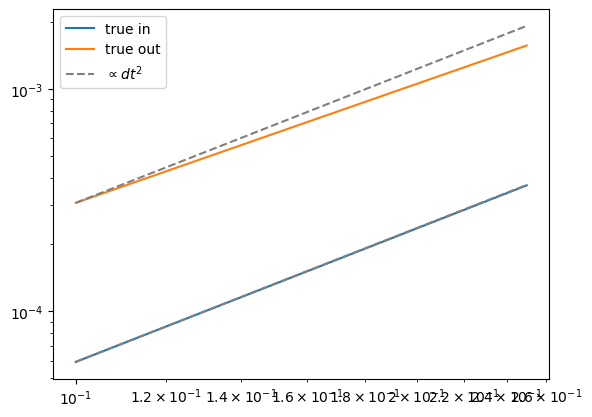

In [94]:
plt.plot(dt_list, [true_dt2_analysis_in["L1"].mean(), true_dt5_analysis_in["L1"].mean()], label='true in')
plt.plot(dt_list, [true_dt2_analysis_out["L1"].mean(), true_dt5_analysis_out["L1"].mean()], label='true out')
plt.plot(dt_list, (true_dt2_analysis_in["L1"].mean()/(dt_list[0]**2))*dt_list**2, color='grey', linestyle='--', label=r'$\propto dt^2$')
plt.xscale('log')
plt.plot(dt_list, (true_dt2_analysis_out["L1"].mean()/(dt_list[0]**2))*dt_list**2, color='grey', linestyle='--')

plt.yscale('log')
plt.legend()

In [75]:
aug_dt2_analysis_in = analysis(aug_dt2_data_in, "aug_dt2_in")
aug_dt2_analysis_out = analysis(aug_dt2_data_out, "aug_dt2_out")
aug_dt5_analysis_in = analysis(aug_dt5_data_in, "aug_dt5_in")
aug_dt5_analysis_out = analysis(aug_dt5_data_out, "aug_dt5_out")

Analysis of aug_dt2_in
Mean L1 error: 0.0008490964537486434
p_inf_true_mean over 100 last s: 1.258248062185885e-06
p_inf_pred_mean over 100 last s: 5.329152918420732e-05
q_inf_modulo2pi_true: [9.834766e-07]
q_inf_modulo2pi_pred: [0.000198]
Number of physical trajectories pred: 16
Number of physical trajectories true: 16
Analysis of aug_dt2_out
Mean L1 error: 0.08385375142097473
p_inf_true_mean over 100 last s: 9.938915354723576e-06
p_inf_pred_mean over 100 last s: 0.0003502086328808218
q_inf_modulo2pi_true: [7.4836944e-06]
q_inf_modulo2pi_pred: [0.00187443]
Number of physical trajectories pred: 36
Number of physical trajectories true: 36
Analysis of aug_dt5_in
Mean L1 error: 0.19184260070323944
p_inf_true_mean over 100 last s: 1.258248062185885e-06
p_inf_pred_mean over 100 last s: 0.000514142622705549
q_inf_modulo2pi_true: [9.834766e-07]
q_inf_modulo2pi_pred: [0.00176164]
Number of physical trajectories pred: 16
Number of physical trajectories true: 16
Analysis of aug_dt5_out
Mean L1 e

In [96]:
aug_dt2_analysis_in["L1"]

0.00084909645

Text(0.5, 1.0, 'L1 error')

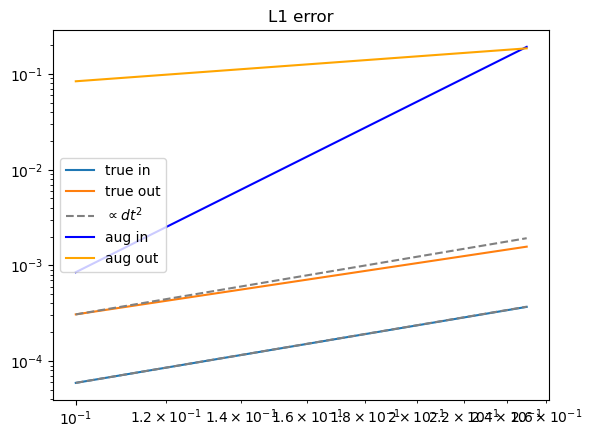

In [99]:
plt.plot(dt_list, [true_dt2_analysis_in["L1"], true_dt5_analysis_in["L1"]], label='true in')
plt.plot(dt_list, [true_dt2_analysis_out["L1"], true_dt5_analysis_out["L1"]], label='true out')
plt.plot(dt_list, (true_dt2_analysis_in["L1"]/(dt_list[0]**2))*dt_list**2, color='grey', linestyle='--', label=r'$\propto dt^2$')
plt.plot(dt_list, (true_dt2_analysis_out["L1"]/(dt_list[0]**2))*dt_list**2, color='grey', linestyle='--')


plt.plot(dt_list, [aug_dt2_analysis_in["L1"], aug_dt5_analysis_in["L1"]], label='aug in',color='blue')
plt.plot(dt_list, [aug_dt2_analysis_out["L1"], aug_dt5_analysis_out["L1"]], label='aug out',color='orange')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("L1 error")

t1=20 (entraine pour 20s)

In [14]:
def F(y,t):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2 * y[1]])
t0=0

In [24]:
true_dt2_in = compute_trajectories(F, y0_in, dt_truth=0.05, dt_factor=2,)
true_dt2_out = compute_trajectories(F, y0_out, dt_truth=0.05, dt_factor=2)
true_dt5_in = compute_trajectories(F, y0_in, dt_truth=0.05, dt_factor=5)
true_dt5_out = compute_trajectories(F, y0_out, dt_truth=0.05, dt_factor=5)

l1_true_dt2_in = true_dt2_in.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
l1_true_dt2_out = true_dt2_out.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
l1_true_dt5_in = true_dt5_in.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
l1_true_dt5_out = true_dt5_out.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
print(l1_true_dt2_in.mean(), l1_true_dt2_out.mean(), l1_true_dt5_in.mean(), l1_true_dt5_out.mean()) 

0.00046988032 0.0009872951 0.0033389647 0.0074173403


In [23]:
aug_dt2_in = compute_trajectories(F_aug2, y0_in, dt_truth=0.05, dt_factor=2)
aug_dt2_out = compute_trajectories(F_aug2, y0_out, dt_truth=0.05, dt_factor=2)
aug_dt5_in = compute_trajectories(F_aug5, y0_in, dt_truth=0.05, dt_factor=5)
aug_dt5_out = compute_trajectories(F_aug5, y0_out, dt_truth=0.05, dt_factor=5)

l1_aug_dt2_in = aug_dt2_in.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
l1_aug_dt2_out = aug_dt2_out.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
l1_aug_dt5_in = aug_dt5_in.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
l1_aug_dt5_out = aug_dt5_out.apply(lambda x: np.mean(np.abs(x["y_true"] - x["y_pred"])), axis=1)
print(l1_aug_dt2_in.mean(), l1_aug_dt2_out.mean(), l1_aug_dt5_in.mean(), l1_aug_dt5_out.mean())

0.0059968177 0.009829808 0.055723052 0.10532011


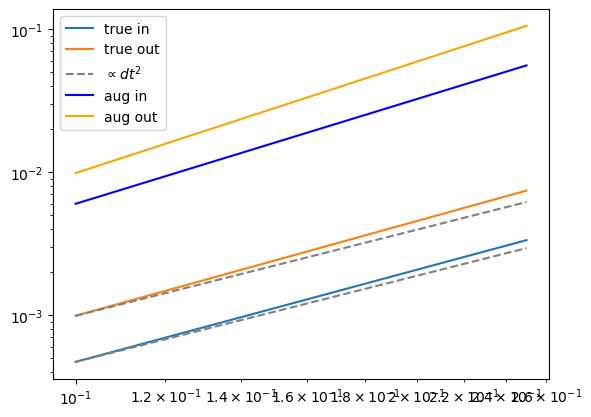

In [25]:
plt.plot(dt_list, [l1_true_dt2_in.mean(), l1_true_dt5_in.mean()], label='true in')
plt.plot(dt_list, [l1_true_dt2_out.mean(), l1_true_dt5_out.mean()], label='true out')
plt.plot(dt_list, (l1_true_dt2_in.mean()/(dt_list[0]**2))*dt_list**2, color='grey', linestyle='--', label=r'$\propto dt^2$')
plt.plot(dt_list, (l1_true_dt2_out.mean()/(dt_list[0]**2))*dt_list**2, color='grey', linestyle='--')
plt.plot(dt_list, [l1_aug_dt2_in.mean(), l1_aug_dt5_in.mean()], label='aug in',color='blue')
plt.plot(dt_list, [l1_aug_dt2_out.mean(), l1_aug_dt5_out.mean()], label='aug out',color='orange')
plt.xscale('log')
plt.yscale('log')
plt.legend()


On test set 

In [22]:
loss_true1_test, net_true1 = simulate_ground_truth(2, 'RK2', 'test')
loss_true2_test, net_true2 = simulate_ground_truth(5, 'RK2','test')
loss_true1_test.mean(), loss_true2_test.mean()

3.3286386e-07
1.1562755e-05


(3.3286386e-07, 1.1562755e-05)

In [28]:
def pred_model(net, dt_factor):
    losses = []
    for i, data in enumerate(test):
        states = jnp.array(data['states'])[:,:,::dt_factor]
        y0 = states[:,:,0]
        pred = jax.vmap(net)(y0)
        losses.append(((pred - states)**2)[0])
    return np.array(losses)

losses_trueaug1 = pred_model(true_aug1, 2)

In [32]:
losses_trueaug2 = pred_model(true_aug2, 5)

In [33]:
losses_trueaug1.mean(axis=(1,2)).mean(), losses_trueaug2.mean(axis=(1,2)).mean()

(4.791733e-07, 7.776696e-06)

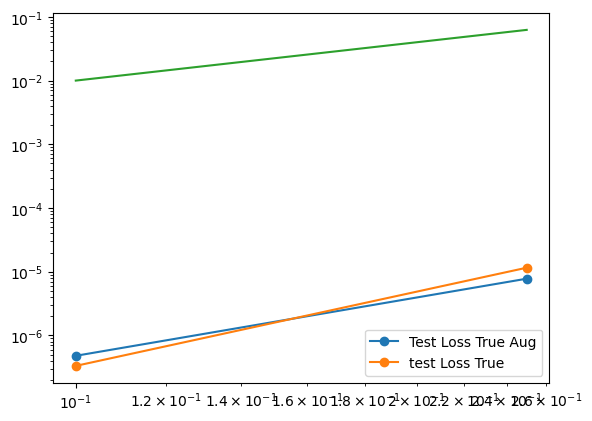

In [48]:
plt.plot(dt_list, [losses_trueaug1.mean(axis=(1,2)).mean(), losses_trueaug2.mean(axis=(1,2)).mean()], marker='o', label='Test Loss True Aug')
plt.plot(dt_list, [loss_true1_test.mean(), loss_true2_test.mean()], marker='o', label='test Loss True')
plt.plot(dt_list, dt_list**2)
plt.xscale('log')
plt.yscale('log')

plt.legend()

In [36]:
# on all domain of y0
from solvers import *
q = np.linspace(-15, 15, 10)
p = np.linspace(-15, 15, 10)
Q, P = np.meshgrid(q, p)

def F(y,t):
    return jnp.array([y[1], -((2*jnp.pi/12)**2) * jnp.sin(y[0]) - 0.2 * y[1]])

t0 = 0 
t1 = 20

def evaluate_all_domain(models, dt_list, t0, t1):
    pred_res = {}
    losses_pred = []
    losses_rk2 = []
    for y0 in zip(Q.ravel(), P.ravel()):
        i =0
        y0=jnp.array(y0)
        truth, _,_,_ = RK_solver_fixed(F,y0,dt_truth, (t1-t0)/dt_truth, RK_tableaux["RK4"])
        #print(truth.shape)
        for model in models:
            dt = dt_list[i]
            pred = model(y0)
            truth_rk2, _,_,_ = RK_solver_fixed(F, y0, dt, (t1-t0)/dt, RK_tableaux["RK2"])
            loss_pred = np.sqrt(np.mean((pred - truth[:,::dt_factors[i]])**2))
            loss_rk2 = np.sqrt(np.mean((truth_rk2 - truth[:,::dt_factors[i]])**2))
            losses_pred.append(loss_pred)
            losses_rk2.append(loss_rk2)
            #pred_res[dt] = {"pred": loss_pred, "truth": loss_rk2}
            i += 1
    return np.array(losses_pred), np.array(losses_rk2)           

eval_pred, eval_rk2 = evaluate_all_domain([true_aug1], dt_list, t0, t1)
eval_pred.mean(), eval_rk2.mean()

(0.028614983, 0.0019961006)

(100,)

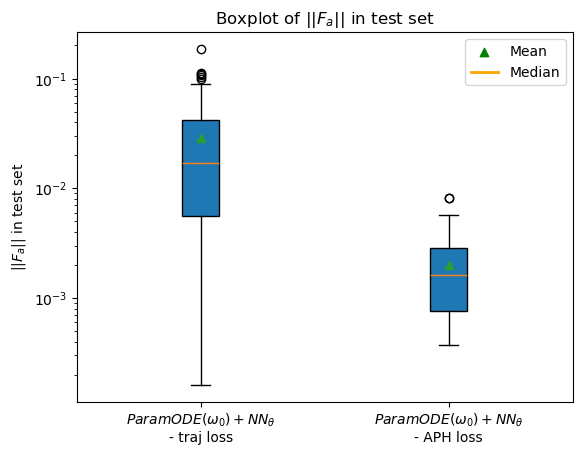

In [40]:
# boxplot 
losses_Fa = [
    eval_pred,
    eval_rk2
]
labels = [r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- traj loss', r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- APH loss']
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel(r'$||F_a||$ in test set')
ax.set_yscale('log')

# orientation en biais
bplot = ax.boxplot(losses_Fa,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   showmeans=True)  # will be used to label x-ticks
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
#outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend], loc='upper right')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(r"Boxplot of $||F_a||$ in test set")
plt.show()



# Restart

In [26]:
# load model 
import json 
from networks import *
import jax
import equinox as eqx
from datasets import *
import os
from forecasters import *

def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method, dt_factor):
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=test.dataset.dt * dt_factor,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op


In [27]:
exp_name = 'true_aug_1_akm7kp32'
model_name = 'model_5.677e-08.eqx'
data_path = 'data/correct_num_err'
model_phy_option = 'true'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK2'
true_aug1, _,_ = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method, dt_factor=2)

exp_name = 'true_aug_2_akm7kp32'
model_name = 'model_2.011e-06.eqx'
data_path = 'data/correct_num_err'
model_phy_option = 'true'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK2'
true_aug2, _,_ = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method, dt_factor=5)

data/correct_num_err/true_aug_1_akm7kp32/model_5.677e-08.eqx
l2
data/correct_num_err/true_aug_2_akm7kp32/model_2.011e-06.eqx
l2
